## Outlier detection using statistical methods

Outliers are data points that differ significantly from the rest of the dataset and do not follow the general pattern. They can occur due to errors, rare events or natural variability in data.

- Appear as unusually high or low values
- Can affect mean, variance, and model performance
- Detected using statistical and visual methods
- Important to analyze before removing or treating them

In [132]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats
import seaborn as sns


In [133]:
df=pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [134]:
df.shape

(284807, 31)

/var/folders/8c/vl52twl13ndg664vk13_bcs80000gn/T/ipykernel_36559/2896111134.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


Text(0, 0.5, 'Frequency')

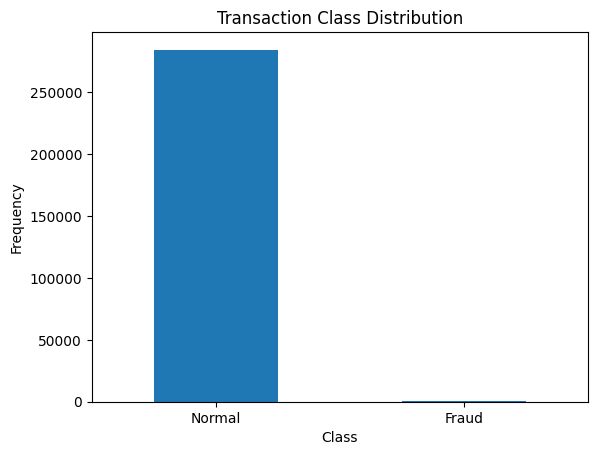

In [135]:
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
LABELS = ["Normal", "Fraud"]
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

## Example
Here as we can see that only 492 cases are of fraud while rest more than 2.8 Lakhs are cases of Normal transactions

In [136]:
fraud = df[df['Class']==1]
normal = df[df['Class']==0]
print(fraud.shape,normal.shape)

(492, 31) (284315, 31)


## Reasons for outliers
- Data Entry Errors: Mistakes made while entering data manually can generate extreme or inconsistent values.
- Measurement Errors: Faulty instruments or incorrect experimental setups can lead to abnormally high or low readings.
- Experimental Errors: Poorly designed experiments may produce results that do not accurately represent the underlying phenomenon.
- Intentional Outliers: Sometimes outliers are introduced deliberately such as in cases of fraud or data manipulation.
- Data Processing Errors: Errors during data collection, cleaning or transformation can introduce unusual values.
- Natural Variation: Some outliers arise naturally due to inherent variability in the population or process being studied.

## Effect of outliers on Algorithms
Algorithms that are severly affected by outliers in data
- Linear Regression
- Logistic Regression
- ADA Boost
- Neural Netorks
A common pattern in these algorithm is that all of them involves weight calculation and optimization

Algorithms that are unaffected by outliers in data
- Decision Tree
- Random Forest
- XG Boost
they cut the dataset into section so they are least affected by outliers


## Treating Outliers in data
1. Trimming 
2. Capping
3. Treat like Missing values
4. Diseretization

## Statistical Methods 
- Z-Score
- Modified Z-Score
- IQR Method
- Grubbs' Test
- Dixon's Q Test
- Mahalanobis Distance



## 1. Outlier Detection using Z score

### Formula
$$Z = \frac{X - \mu}{\sigma}$$

- $X$ = Data point value  
- $\mu$ = Population mean  
- $\sigma$ = Standard deviation  
- **Threshold:** $|Z| > 3$ → Outlier  

### Description
- Measures how many standard deviations a point is from the mean
- Assumes data follows a **Gaussian (Normal)** distribution
- Common threshold: $|Z| > 2.5$ or $3$ flags an outlier
- Best for **unimodal, symmetric** distributions
- Sensitive to outliers itself (non-robust)

In [137]:
df = pd.read_csv('placement.csv')

In [138]:
df.shape

(1000, 3)

In [139]:
df.sample(5)

,cgpa,placement_exam_marks,placed
170,6.17,37.0,0
323,6.60,38.0,0
719,7.17,26.0,0
959,6.76,27.0,1
75,6.77,56.0,1


/var/folders/8c/vl52twl13ndg664vk13_bcs80000gn/T/ipykernel_36559/3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/var/folders/8c/vl52twl13ndg664vk13_bcs80000gn/T/ipykernel_36559/3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


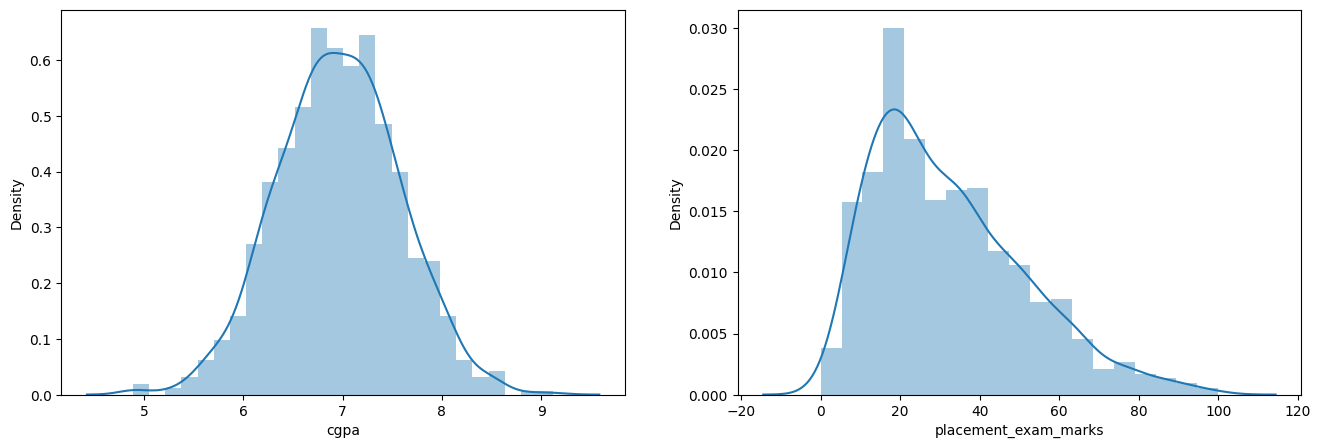

In [140]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

### Z score works good for normally distributed data and not for skewed data so we take the cgpa one

In [141]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [142]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [143]:
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [144]:
# Finding the outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### This dataset has 5 outliers 
	        cgpa	placement_exam_marks	placed
    485	    4.92	44.0	                1
    995	    8.87	44.0	                1
    996	    9.12	65.0	                1
    997	    4.89	34.0	                0
    999	    4.90	10.0	                1


### 1. Trimming

In [145]:
# Trimming

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### 2. Capping

In [146]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [147]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [148]:
df.shape

(1000, 3)

In [149]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

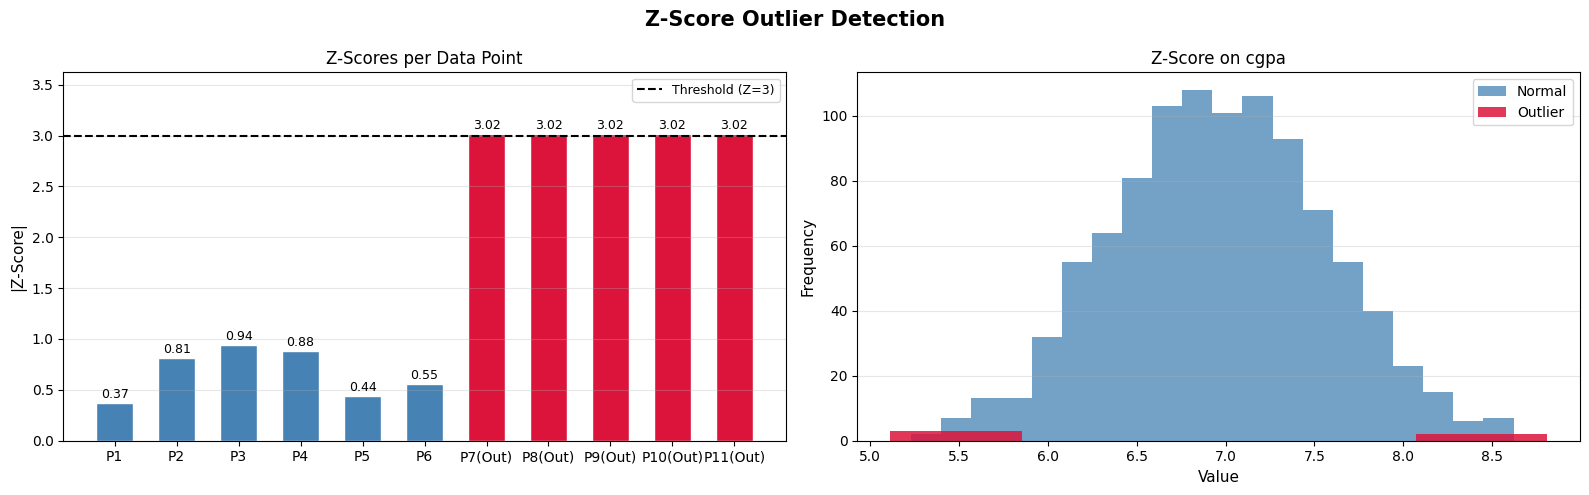


Outliers detected in 'cgpa':
[5.11354637 8.80893363 8.80893363 5.11354637 5.11354637]
Total outliers: 5 / 1000


In [150]:

col = 'cgpa'  # change to 'placement_exam_marks' if needed

data = df[col].dropna().values
z_scores = np.abs(stats.zscore(data))

outlier_mask = z_scores > 3
outliers     = data[outlier_mask]
inliers      = data[~outlier_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Z-Score Outlier Detection', fontsize=15, fontweight='bold')

# ── LEFT: Bar chart of Z-scores per point ──────────────────────────────────
ax1 = axes[0]

# Show only a sample: first 6 inliers + all outliers (like the reference image)
sample_idx    = np.where(~outlier_mask)[0][:6]
outlier_idx   = np.where(outlier_mask)[0]

show_idx      = np.concatenate([sample_idx, outlier_idx])
show_z        = z_scores[show_idx]
show_vals     = data[show_idx]

labels = [f'P{i+1}' for i in range(len(sample_idx))]
for oi in outlier_idx:
    labels.append(f'P{np.where(show_idx == oi)[0][0]+1}(Out)')

bar_colors = ['crimson' if z_scores[i] > 3 else 'steelblue' for i in show_idx]

bars = ax1.bar(labels, show_z, color=bar_colors, width=0.6, edgecolor='white')

# Annotate bars
for bar, z in zip(bars, show_z):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{z:.2f}', ha='center', va='bottom', fontsize=9)

ax1.axhline(y=3, color='black', linestyle='--', linewidth=1.5, label='Threshold (Z=3)')
ax1.set_ylabel('|Z-Score|', fontsize=11)
ax1.set_title('Z-Scores per Data Point', fontsize=12)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(show_z.max() * 1.2, 3.5))
ax1.grid(axis='y', alpha=0.3)

# ── RIGHT: Histogram with outliers in red ──────────────────────────────────
ax2 = axes[1]

ax2.hist(inliers,  bins=20, color='steelblue', alpha=0.75, label='Normal')
ax2.hist(outliers, bins=5,  color='crimson',   alpha=0.85, label='Outlier')

ax2.set_xlabel('Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title(f'Z-Score on {col}', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOutliers detected in '{col}':")
print(df[col][outlier_mask].values)
print(f"Total outliers: {outlier_mask.sum()} / {len(data)}")


## 2. IQR (Interquartile Range) Method

### Formulas
$$\text{IQR} = Q3 - Q1$$
$$\text{Lower Fence} = Q1 - 1.5 \times \text{IQR}$$
$$\text{Upper Fence} = Q3 + 1.5 \times \text{IQR}$$


In [151]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

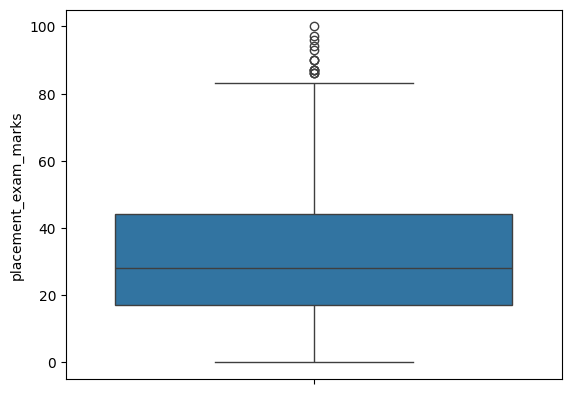

In [152]:
sns.boxplot(df['placement_exam_marks'])

In [153]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [154]:
iqr = percentile75 - percentile25
iqr

27.0

In [155]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [156]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [157]:

df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [158]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [159]:
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.shape

(985, 3)

/var/folders/8c/vl52twl13ndg664vk13_bcs80000gn/T/ipykernel_36559/3691338288.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
/var/folders/8c/vl52twl13ndg664vk13_bcs80000gn/T/ipykernel_36559/3691338288.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['plac

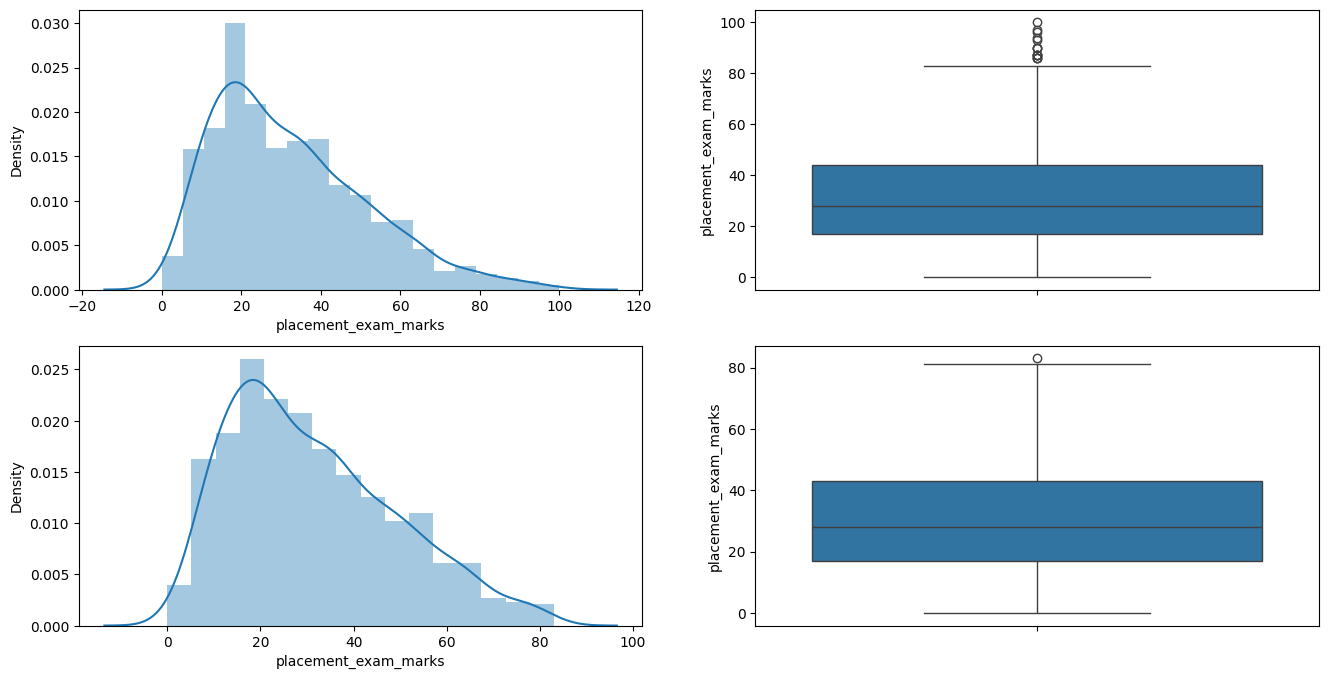

In [160]:

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

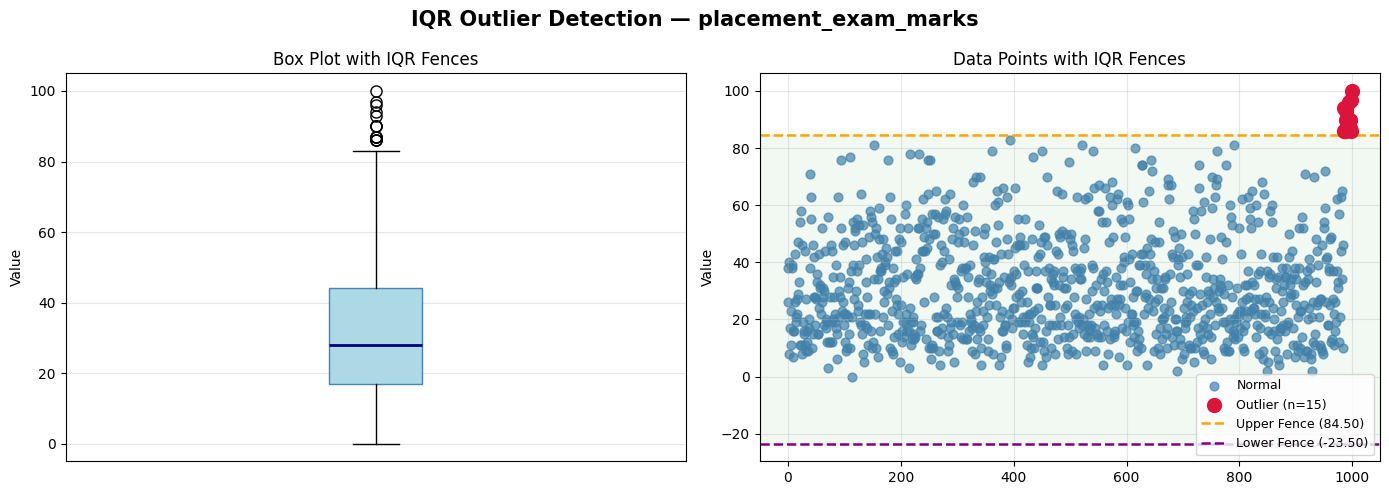

In [161]:
# Uses variables already defined in your notebook
iqr_data     = df['placement_exam_marks'].values
outlier_mask = (iqr_data > upper_limit) | (iqr_data < lower_limit)
upper        = upper_limit
lower        = lower_limit

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IQR Outlier Detection — placement_exam_marks', fontsize=15, fontweight='bold')

# LEFT: Box Plot
axes[0].boxplot(iqr_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='navy', linewidth=2),
                flierprops=dict(marker='o', color='crimson', markersize=8))
axes[0].set_title('Box Plot with IQR Fences')
axes[0].set_ylabel('Value')
axes[0].set_xticks([])
axes[0].grid(axis='y', alpha=0.3)

# RIGHT: Scatter with fences
normal_pts  = iqr_data[~outlier_mask]
outlier_pts = iqr_data[ outlier_mask]

axes[1].scatter(range(len(normal_pts)), normal_pts,
                color='steelblue', alpha=0.7, label='Normal', s=40)
axes[1].scatter([len(normal_pts) + i for i in range(len(outlier_pts))], outlier_pts,
                color='crimson', s=100, zorder=5, label=f'Outlier (n={outlier_mask.sum()})')
axes[1].axhline(upper, color='orange', linestyle='--', linewidth=1.8,
                label=f'Upper Fence ({upper:.2f})')
axes[1].axhline(lower, color='purple', linestyle='--', linewidth=1.8,
                label=f'Lower Fence ({lower:.2f})')
axes[1].axhspan(lower, upper, alpha=0.05, color='green')
axes[1].set_title('Data Points with IQR Fences')
axes[1].set_ylabel('Value')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Percentile Based

In [162]:
upper_limit = df['cgpa'].quantile(0.99)
upper_limit

8.4201

In [163]:
lower_limit1 = df['cgpa'].quantile(0.01)
lower_limit1

5.5596

In [164]:
new_df = df[(df['cgpa'] <= upper_limit) & (df['cgpa'] >= lower_limit1)]

In [165]:
new_df.shape

(980, 3)

<Axes: ylabel='cgpa'>

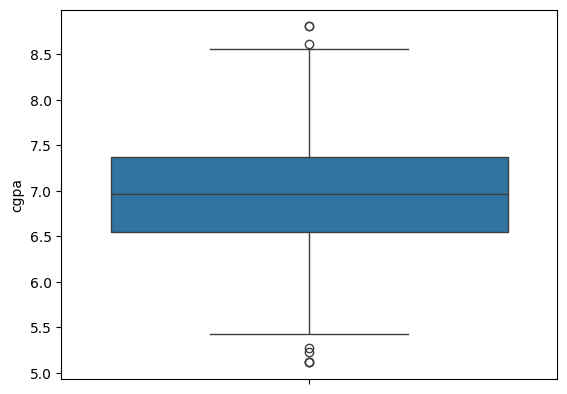

In [166]:
sns.boxplot(df['cgpa'])

<Axes: ylabel='cgpa'>

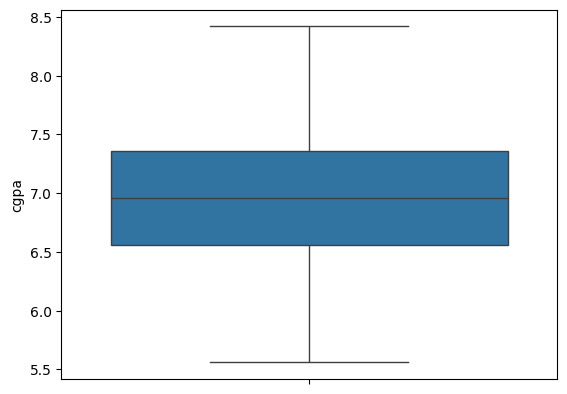

In [167]:
sns.boxplot(new_df['cgpa'])


## 4. Modified Z score

In [168]:

def modified_z_score(data):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    M = 0.6745 * (data - median) / mad
    return M

# Apply
col = 'cgpa'
data = df[col].dropna().values
M_scores = modified_z_score(data)

outlier_mask = np.abs(M_scores) > 3.5
outliers = data[outlier_mask]

print(f"Outliers detected: {outliers}")
print(f"Total: {outlier_mask.sum()} / {len(data)}")

Outliers detected: []
Total: 0 / 1000
